# Fused Gromov--Wasserstein: features versus geometry

This notebook generates `fig:fused-gromov-feature-geometry`.  Fused GW combines a feature cost and an intrinsic-distance cost.  The two point clouds are nearly isometric, but their binary node features are deliberately shifted.  The three panels compare feature-only OT, fused GW, and pure GW.

In [1]:
from pathlib import Path
import os
import sys
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")
for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse
from PIL import Image
import ot
from scipy.linalg import expm, solve
from scipy.spatial.distance import cdist
from scipy.ndimage import gaussian_filter
from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY, DIRAC_MARKER_SIZE,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, box_axes,
    interp_color, draw_point_clouds, draw_transport_segments, padded_limits,
)
setup_matplotlib()
rng = np.random.default_rng(2027)

In [2]:
NAME='fused-gromov-feature-geometry'; out=figure_dir(NAME)
n=14; t=np.linspace(0,1,n)
x=np.c_[0.26*np.sin(2*np.pi*t),1.56*(t-0.5)]
y0=x + np.c_[0.12*np.sin(3*np.pi*t), -0.05*np.cos(2*np.pi*t)]
features_x=(t>0.48).astype(int); features_y=np.roll(features_x,4)
M=(features_x[:,None]-features_y[None,:])**2 + 0.05*ot.dist(x,y0)
C1=ot.dist(x,x); C2=ot.dist(y0,y0); C1/=C1.max(); C2/=C2.max()
a=np.ones(n)/n; b=np.ones(n)/n
T_ot=ot.emd(a,b,M.astype(float))
T_fgw=ot.gromov.fused_gromov_wasserstein(M.astype(float),C1,C2,a,b,loss_fun='square_loss',alpha=0.62,G0=np.eye(n)/n,epsilon=1e-3,max_iter=400,tol=1e-10,verbose=False)
T_gw=ot.gromov.gromov_wasserstein(C1,C2,a,b,'square_loss',G0=np.eye(n)/n,epsilon=1e-3,max_iter=400,tol=1e-10,verbose=False)
xd=x+np.array([-1.05,0]); yd=y0+np.array([1.05,0]); pts=np.vstack([xd,yd]); xlim,ylim=padded_limits(pts,pad=0.10)
pal=np.array([ORANGE,VIOLET])
def panel(T,fn):
    fig,ax=plt.subplots(figsize=(2.45,1.95))
    pairs=[(i,int(np.argmax(T[i])),float(T[i].max())) for i in range(n)]
    draw_transport_segments(ax,xd,yd,pairs,color=GRAY,max_width=1.02,alpha_scale=0.46,zorder=1)
    draw_point_clouds(ax,xd,yd,base_size=DIRAC_MARKER_SIZE*1.05)
    ax.scatter(xd[:,0],xd[:,1],s=5.2,c=pal[features_x],marker='o',edgecolor='none',linewidth=0,zorder=5)
    ax.scatter(yd[:,0],yd[:,1],s=5.2,c=pal[features_y],marker='o',edgecolor='none',linewidth=0,zorder=5)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal'); remove_axes(ax)
    save_pdf(fig,out/fn,pad_inches=0.045); plt.close(fig)
panel(T_ot,'feature-ot.pdf'); panel(T_fgw,'fused-gw.pdf'); panel(T_gw,'pure-gw.pdf')

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


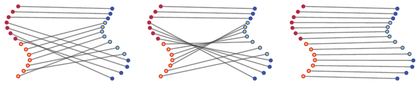

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/fused-gromov-feature-geometry.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/fused-gromov-feature-geometry.png")
display(Image(filename=str(_thumb)))
